### Instalar as bibliotecas necessárias:

Abra o terminal e execute os seguintes comandos:

In [11]:
pip install pandas pyarrow duckdb matplotlib

  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp313-cp313-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp313-cp313-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl (73 kB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ---------------------------------------- 0/6 [pyparsing]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- --


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Baixar o conjunto de dados:

    Baixe um arquivo CSV grande (ex.: logs de navegação ou vendas) ou gere um conjunto de dados sintético usando Python:

In [5]:
import pandas as pd
import numpy as np

# Gerar dados sintéticos
data = {
    "UserID": np.random.randint(1, 1000, 100000),
    "Timestamp": pd.date_range(start="2023-01-01", periods=100000, freq="s"),
    "URLVisitada": [f"pagina_{i % 10}" for i in range(100000)],
    "TempoSessao": np.random.randint(10, 300, 100000)
}
df = pd.DataFrame(data)
df.to_csv("dados_logs.csv", index=False)


### Converter o CSV para formato colunar (Parquet):

    Use o Pandas para converter o CSV em um arquivo Parquet:

In [6]:
import pandas as pd

# Ler o CSV
df = pd.read_csv("dados_logs.csv")

# Salvar como Parquet
df.to_parquet("dados_logs.parquet", engine="pyarrow")

### Parte 2: Consultas Analíticas

    Carregar o arquivo Parquet com DuckDB:
        DuckDB é uma ferramenta leve que suporta consultas SQL em arquivos Parquet. Execute o seguinte código:

In [7]:
import duckdb

# Conectar ao DuckDB
con = duckdb.connect()

# Carregar o arquivo Parquet
con.execute("CREATE TABLE logs AS SELECT * FROM read_parquet('dados_logs.parquet')")

### Executar consultas analíticas:

    Execute consultas SQL para explorar os dados:

In [8]:
# Contagem de visitas por página
result = con.execute("""
    SELECT URLVisitada, COUNT(*) AS TotalVisitas
    FROM logs
    GROUP BY URLVisitada
    ORDER BY TotalVisitas DESC
""").fetchall()

print(result)

# Média de tempo de sessão por usuário
result = con.execute("""
    SELECT UserID, AVG(TempoSessao) AS MediaTempoSessao
    FROM logs
    GROUP BY UserID
    ORDER BY MediaTempoSessao DESC
""").fetchall()

print(result)

[('pagina_0', 10000), ('pagina_5', 10000), ('pagina_2', 10000), ('pagina_4', 10000), ('pagina_1', 10000), ('pagina_3', 10000), ('pagina_6', 10000), ('pagina_8', 10000), ('pagina_7', 10000), ('pagina_9', 10000)]
[(237, 182.3877551020408), (438, 180.82291666666666), (763, 180.1290322580645), (286, 177.80612244897958), (424, 176.9878048780488), (964, 176.61764705882354), (151, 176.05714285714285), (869, 175.5326086956522), (682, 175.2929292929293), (483, 174.65765765765767), (333, 174.37864077669903), (269, 174.33333333333334), (503, 174.13483146067415), (739, 174.125), (444, 174.10752688172042), (259, 173.84466019417476), (686, 173.73563218390805), (543, 173.60638297872342), (631, 172.83516483516485), (47, 172.7578947368421), (321, 172.75), (853, 172.48717948717947), (519, 172.14423076923077), (913, 172.09677419354838), (557, 172.02777777777777), (920, 171.90526315789472), (464, 171.06451612903226), (720, 171.0), (870, 170.73267326732673), (825, 170.59259259259258), (743, 170.39622641509

### Comparar desempenho entre CSV e Parquet:

    Compare o tempo de execução das mesmas consultas em um arquivo CSV e no arquivo Parquet:

In [19]:
import time

# Consulta no CSV
start_time = time.time()
df_csv = pd.read_csv("dados_logs.csv")
df_csv.groupby("URLVisitada").size().reset_index(name="TotalVisitas")
print(f"Tempo CSV: {time.time() - start_time}")

# Consulta no Parquet
start_time = time.time()
df_parquet = pd.read_parquet("dados_logs.parquet")
df_parquet.groupby("URLVisitada").size().reset_index(name="TotalVisitas")
print(f"Tempo Parquet: {time.time() - start_time}")

Tempo CSV: 0.0812063217163086
Tempo Parquet: 0.008041858673095703


### Parte 3: Análise dos Resultados

    Discussão em sala:
        Quais foram as diferenças de desempenho entre o CSV e o Parquet?
        Por que o formato colunar (Parquet) é mais eficiente para consultas analíticas?
    Visualização dos dados:
        Use uma ferramenta gráfica (ex.: Matplotlib ou Seaborn) para visualizar os resultados das consultas:

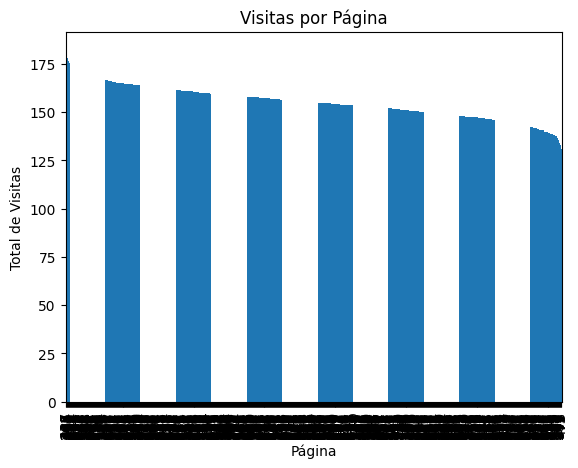

In [15]:
import matplotlib.pyplot as plt

# Visualizar contagem de visitas por página
df_result = pd.DataFrame(result, columns=["URLVisitada", "TotalVisitas"])
df_result.plot(kind="bar", x="URLVisitada", y="TotalVisitas", legend=False)
plt.title("Visitas por Página")
plt.xlabel("Página")
plt.ylabel("Total de Visitas")
plt.show()

### Conclusão

    Resumo:
        Bancos de dados colunares, como o Amazon Redshift, utilizam formatos semelhantes ao Parquet para otimizar consultas analíticas.
        O formato colunar reduz o tempo de leitura e melhora o desempenho em grandes volumes de dados.
    Reflexão:
        Em quais cenários você usaria um banco de dados colunar em vez de um relacional?